In [ ]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sb

nombres=[x for x in range(1,25)]+['Resultado']
datos = pd.read_csv('german.data-numeric', sep='\s+', header=None, names=nombres)

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
C:\Users\emili\AppData\Local\Temp\ipykernel_19784\3140155904.py:7: SyntaxWarning: invalid escape sequence '\s'
  datos = pd.read_csv('german.data-numeric', sep='\s+', header=None, names=nombres)


In [2]:
print(datos)

# Captura de datos tomando, quitando la columna de resultados
X=datos.drop(labels=datos.columns[-1], axis=1)

     1   2  3   4  5  6  7  8  9  10  ...  16  17  18  19  20  21  22  23  24  \
0    1   6  4  12  5  5  3  4  1  67  ...   0   0   1   0   0   1   0   0   1   
1    2  48  2  60  1  3  2  2  1  22  ...   0   0   1   0   0   1   0   0   1   
2    4  12  4  21  1  4  3  3  1  49  ...   0   0   1   0   0   1   0   1   0   
3    1  42  2  79  1  4  3  4  2  45  ...   0   0   0   0   0   0   0   0   1   
4    1  24  3  49  1  3  3  4  4  53  ...   1   0   1   0   0   0   0   0   1   
..  ..  .. ..  .. .. .. .. .. ..  ..  ...  ..  ..  ..  ..  ..  ..  ..  ..  ..   
995  4  12  2  17  1  4  2  4  1  31  ...   0   0   1   0   0   1   0   1   0   
996  1  30  2  39  1  3  1  4  2  40  ...   0   1   1   0   0   1   0   0   0   
997  4  12  2   8  1  5  3  4  3  38  ...   0   0   1   0   0   1   0   0   1   
998  1  45  2  18  1  3  3  4  4  23  ...   0   0   1   0   0   0   0   0   1   
999  2  45  4  46  2  1  3  4  3  27  ...   0   1   1   0   0   1   0   0   1   

     Resultado  
0         

Varianza capturada por 2 componentes: 19.33%


<Axes: >

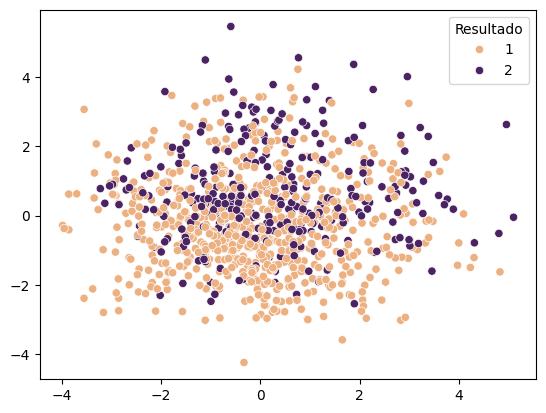

In [3]:
escal = StandardScaler()
X_escalados = escal.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_escalados)

# Varianza 
print(f"Varianza capturada por 2 componentes: {pca.explained_variance_ratio_.sum():.2%}")

#Gráfica
sb.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=datos['Resultado'], palette='flare')

<Axes: >

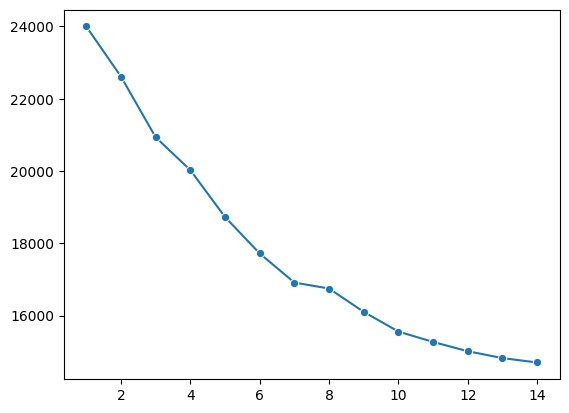

In [ ]:
from sklearn.cluster import KMeans

inercia=[]
for k in range(1,15):
    kmeans = KMeans(n_clusters=k, random_state=777)
    kmeans.fit(X_escalados)
    inercia.append(kmeans.inertia_)
sb.lineplot(x=range(1,15), y=inercia, marker='o')


<Axes: >

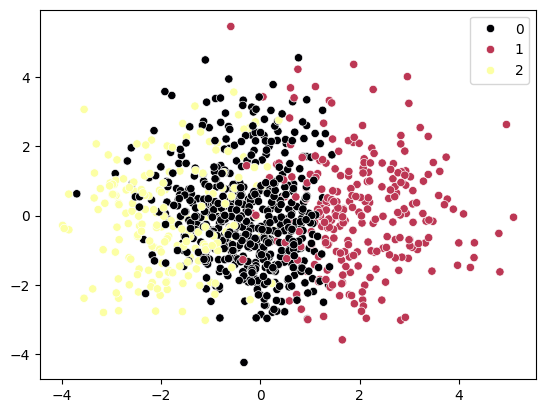

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=777)
k_clases = kmeans.fit_predict(X_escalados)

sb.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=k_clases, palette='flare')

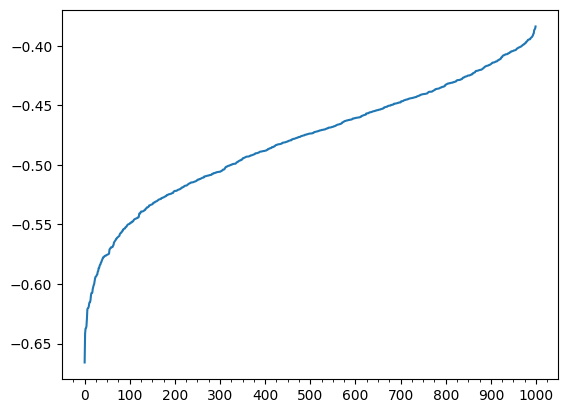

In [87]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

isoforest=IsolationForest(contamination="auto", random_state=777)
clases_isoforest=isoforest.fit_predict(X)

aux=isoforest.score_samples(X)
aux.sort()
ejes= sb.lineplot(x=range(len(aux)),y=aux, markers="o",)
ejes.xaxis.set_major_locator(ticker.MultipleLocator(100))
ejes.xaxis.set_minor_locator(ticker.MultipleLocator(25))
plt.show()

<Axes: >

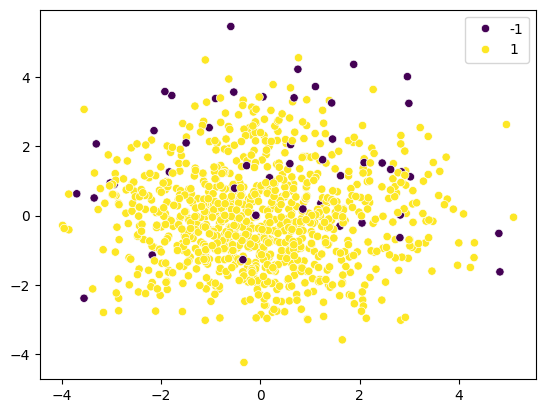

In [88]:
isoforest=IsolationForest(contamination=0.05,random_state=777)
clases_isoforest=isoforest.fit_predict(X)

sb.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=clases_isoforest, palette="viridis")

C:\Users\emili\AppData\Local\Temp\ipykernel_19784\3122293431.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  tabla=sb.barplot(x=["Cluster 0","Cluster 1","Cluster 2"],y=porcentaje_kmeans_isolation, palette="flare")


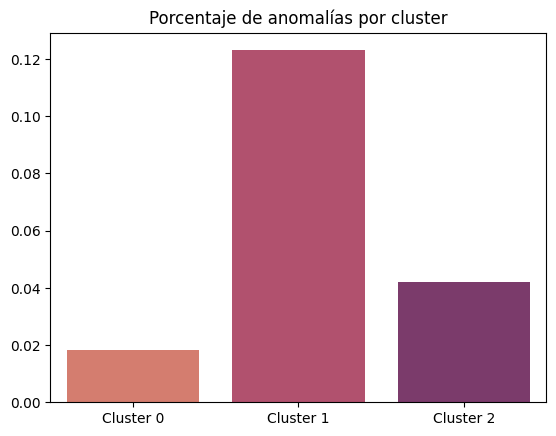

In [79]:
porcentaje_kmeans_isolation=[0,0,0]

no_supervisado=pd.DataFrame(
    {
        "K_Means": k_clases,
        "Isolatio_Forest": clases_isoforest
    }
)

interseccion = no_supervisado[no_supervisado['Isolatio_Forest'] == -1]

porcentaje_kmeans_isolation[0]=(interseccion['K_Means']==0).sum()/((k_clases==0).sum())
porcentaje_kmeans_isolation[1]=(interseccion['K_Means']==1).sum()/((k_clases==1).sum())
porcentaje_kmeans_isolation[2]=(interseccion['K_Means']==2).sum()/((k_clases==2).sum())

tabla=sb.barplot(x=["Cluster 0","Cluster 1","Cluster 2"],y=porcentaje_kmeans_isolation, palette="flare")
tabla.set(title="Porcentaje de anomalías por cluster")
plt.show()

C:\Users\emili\AppData\Local\Temp\ipykernel_19784\4128075557.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  tabla=sb.barplot(x=["Cluster 0","Cluster 1","Cluster 2"],y=proba_cluster, palette="flare")


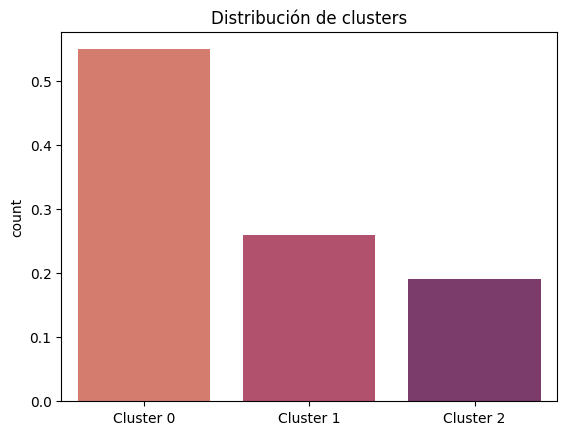

In [80]:
proba_cluster=no_supervisado["K_Means"].value_counts()/len(no_supervisado)
proba_anomalia=(no_supervisado["Isolatio_Forest"]==-1).sum()/len(no_supervisado)

tabla=sb.barplot(x=["Cluster 0","Cluster 1","Cluster 2"],y=proba_cluster, palette="flare")
tabla.set(title="Distribución de clusters")
plt.show()

C:\Users\emili\AppData\Local\Temp\ipykernel_19784\2207583606.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  tabla=sb.barplot(x=["Cluster 0","Cluster 1","Cluster 2"],y=probabilidad_bayes, palette="flare")


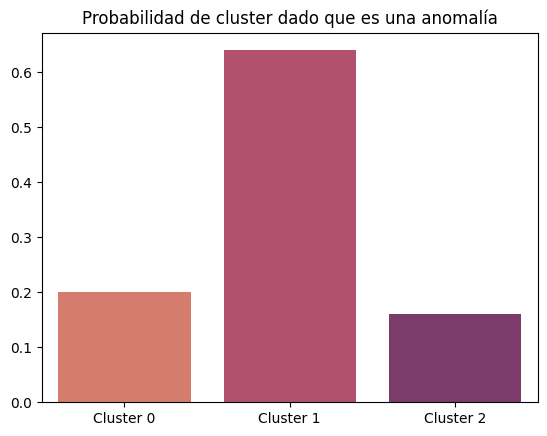

In [81]:
probabilidad_bayes=[0,0,0]

probabilidad_bayes[0]=(porcentaje_kmeans_isolation[0]*proba_cluster[0])/proba_anomalia
probabilidad_bayes[1]=(porcentaje_kmeans_isolation[1]*proba_cluster[1])/proba_anomalia
probabilidad_bayes[2]=(porcentaje_kmeans_isolation[2]*proba_cluster[2])/proba_anomalia

tabla=sb.barplot(x=["Cluster 0","Cluster 1","Cluster 2"],y=probabilidad_bayes, palette="flare")
tabla.set(title="Probabilidad de cluster dado que es una anomalía")
plt.show()

In [91]:
nombres=[x for x in range(1,20)]+['Resultado']
datos_2=pd.read_csv('german.data', sep='\s+', header=None, names=nombres)
X=datos_2.drop(labels=datos_2["Resultado"], axis=1)
Y=datos_2["Resultado"]

X.head()

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\emili\AppData\Local\Temp\ipykernel_19784\3877274471.py:2: SyntaxWarning: invalid escape sequence '\s'
  datos_2=pd.read_csv('german.data', sep='\s+', header=None, names=nombres)


,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,Resultado
A11,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
A12,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
A14,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
A11,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
A11,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2
